In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import cifar10

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train :", x_train.shape)
print("Test :", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train : (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


In [ ]:
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

print("Après flatten :", x_train.shape)

Après flatten : (50000, 3072)


In [ ]:
pca = PCA(n_components=100)

x_train_pca = pca.fit_transform(x_train)

x_test_pca = pca.transform(x_test)

print("Après PCA :", x_train_pca.shape)


Après PCA : (50000, 100)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)


In [ ]:
start = time.time()

model.fit(x_train_pca, y_train)

training_time = time.time() - start

print(f"\nTemps entraînement : {training_time:.2f} secondes")


Temps entraînement : 108.46 secondes


In [ ]:
y_pred = model.predict(x_test_pca)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("\nClassification Report :")

print(classification_report(
    y_test,
    y_pred
))


Accuracy : 0.4656

Classification Report :
              precision    recall  f1-score   support

           0       0.56      0.56      0.56      1000
           1       0.53      0.56      0.55      1000
           2       0.38      0.28      0.33      1000
           3       0.33      0.27      0.30      1000
           4       0.44      0.41      0.42      1000
           5       0.39      0.38      0.38      1000
           6       0.45      0.60      0.51      1000
           7       0.52      0.46      0.49      1000
           8       0.54      0.63      0.58      1000
           9       0.46      0.49      0.48      1000

    accuracy                           0.47     10000
   macro avg       0.46      0.47      0.46     10000
weighted avg       0.46      0.47      0.46     10000



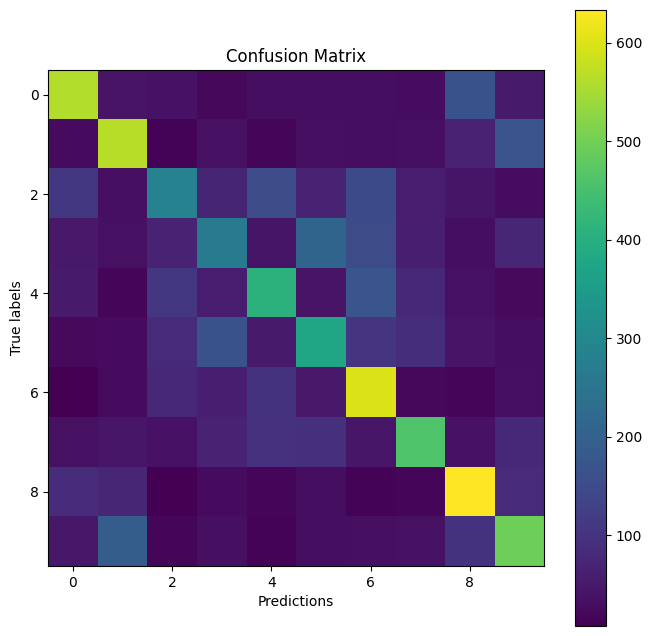

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predictions")

plt.ylabel("True labels")

plt.colorbar()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, log_loss

# Prédictions classes
train_pred = model.predict(x_train_pca)
test_pred = model.predict(x_test_pca)

# Probabilités (nécessaires pour la loss)
train_proba = model.predict_proba(x_train_pca)
test_proba = model.predict_proba(x_test_pca)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# Loss
train_loss = log_loss(y_train, train_proba)
test_loss = log_loss(y_test, test_proba)

# Affichage
print("\n===== RESULTATS =====")

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

print(f"Train Loss     : {train_loss:.4f}")
print(f"Test Loss      : {test_loss:.4f}")


===== RESULTATS =====
Train Accuracy : 0.9963
Test Accuracy  : 0.4656
Train Loss     : 0.5469
Test Loss      : 1.7200
